**1. DATA LOADING AND INITIAL INSPECTION**

In [12]:
# Environment setup

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Uncomment this if you can try the code on your google drive space
#from google.colab import drive

warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


In [13]:
# Define the paths and names
FILE_NAME = 'Loan_default.csv'
# "raw" URL from GitHub
GITHUB_RAW_URL = "https://raw.githubusercontent.com/Leonardo-Cortez/credit_risk_project_loan_default/main/Credit_Risk_Project/data/raw/Loan_default.csv"

# Automatic download if the file is not in the Colab environment
if not os.path.exists(FILE_NAME):
    print("Downloading dataset from GitHub...")
    try:
        # using pandas to download and save files locally
        df_temp = pd.read_csv(GITHUB_RAW_URL, encoding='latin-1')
        df_temp.to_csv(FILE_NAME, index=False)
        print("Download complete.")
    except Exception as e:
        print(f"Critical Error: Could not download the dataset from GitHub. {e}")

# try-except (read the downloaded local file)
file_path = FILE_NAME

try:
    df = pd.read_csv(file_path, encoding='latin-1')
    print('Dataset loaded successfully')
except FileNotFoundError:
    print(f"Error: The file was not found at '{file_path}'")
except Exception as e:
    print(f"Error loading the dataset: {e}")

Dataset loaded successfully


In [14]:
# Google drive connection
# Uncomment this if you can try the code on your google drive space
"""
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Credit_Risk_Project/data/raw/Loan_default.csv"
"""

'\ndrive.mount(\'/content/drive\')\nfile_path = "/content/drive/MyDrive/Credit_Risk_Project/data/raw/Loan_default.csv"\n'

In [15]:
# Dataset loading
# Uncomment this if you can try the code on your google drive space
"""
try:
  df = pd.read_csv(file_path, encoding='latin-1')
  print('Dataset loaded succesfully')
except FileNotFoundError:
  print(f"Error: The file was not found at '{file_path}'")
except Exception as e:
  print(f"Error loading the dataset: {e}")
"""

'\ntry:\n  df = pd.read_csv(file_path, encoding=\'latin-1\')\n  print(\'Dataset loaded succesfully\')\nexcept FileNotFoundError:\n  print(f"Error: The file was not found at \'{file_path}\'")\nexcept Exception as e:\n  print(f"Error loading the dataset: {e}")\n'

In [16]:
# Exploring dataset

print(f"\nDataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nDataset first rows:")
print(df.head())


Dataset dimensions: 255347 rows and 18 columns

Dataset first rows:
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      D

In [17]:
print(f"\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 


**2. DATA QUALITY**

In [18]:
# Missing values analysis

print(f"\nPercentage of missing values:")
missing_values = df.isnull().mean() * 100
print(missing_values[missing_values > 0 ] if missing_values.any() else "There are no missing values")

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_report.sort_values(
    by="Percentage",
    ascending=False
)


Percentage of missing values:
There are no missing values


,Missing Values,Percentage
LoanID,0,0.0
Age,0,0.0
Income,0,0.0
LoanAmount,0,0.0
CreditScore,0,0.0
MonthsEmployed,0,0.0
NumCreditLines,0,0.0
InterestRate,0,0.0
LoanTerm,0,0.0
DTIRatio,0,0.0


In [19]:
# Duplicates analysis
# Detecting and dropping duplicates

duplicates = df.duplicated().sum()
print(f"\nNumber of rows duplicated: {duplicates}")

if duplicates > 0:
  df = df.drop_duplicates()
  print(f"Duplicates removed. New dimensions: {df.shape}")
else:
  print("No duplicates founded")


Number of rows duplicated: 0
No duplicates founded


In [20]:
# ID's duplicated
print(f"\nNumber of duplicated ID's: {df['LoanID'].duplicated().sum()}")


Number of duplicated ID's: 0


**3. TARGET ANALYSIS**

In [21]:
print(df['Default'].value_counts())

Default
0    225694
1     29653
Name: count, dtype: int64


In [22]:
df["Default"].value_counts(normalize=True)*100

,proportion
Default,
0,88.387175
1,11.612825


**4. DESCRIPTIVE STATISTIC**

In [23]:
print(df.describe().T)

                   count           mean           std      min       25%  \
Age             255347.0      43.498306     14.990258     18.0     31.00   
Income          255347.0   82499.304597  38963.013729  15000.0  48825.50   
LoanAmount      255347.0  127578.865512  70840.706142   5000.0  66156.00   
CreditScore     255347.0     574.264346    158.903867    300.0    437.00   
MonthsEmployed  255347.0      59.541976     34.643376      0.0     30.00   
NumCreditLines  255347.0       2.501036      1.117018      1.0      2.00   
InterestRate    255347.0      13.492773      6.636443      2.0      7.77   
LoanTerm        255347.0      36.025894     16.969330     12.0     24.00   
DTIRatio        255347.0       0.500212      0.230917      0.1      0.30   
Default         255347.0       0.116128      0.320379      0.0      0.00   

                      50%        75%       max  
Age                 43.00      56.00      69.0  
Income           82466.00  116219.00  149999.0  
LoanAmount      

**5. DISTRIBUTION OF NUMERICAL VARIABLES**

In [24]:
# Define numerical variables

numerical_columns = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

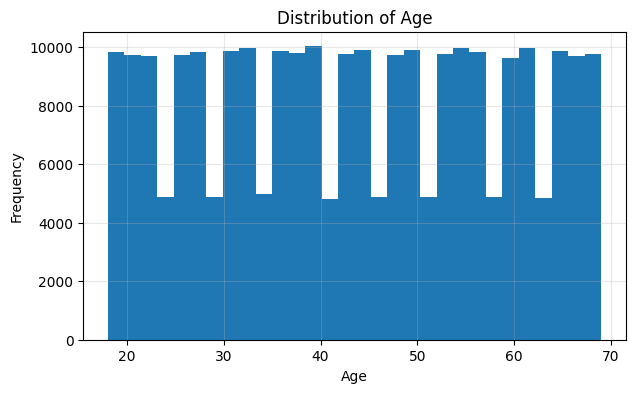

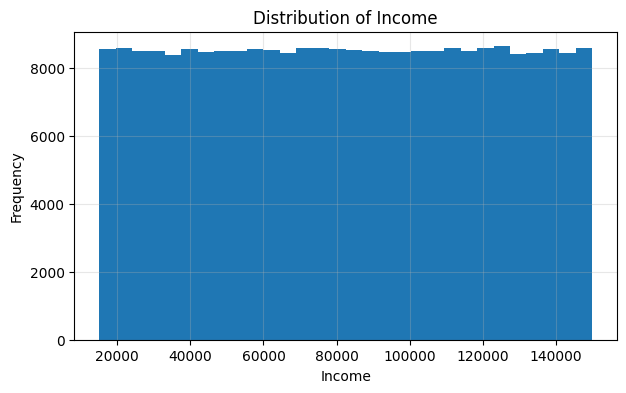

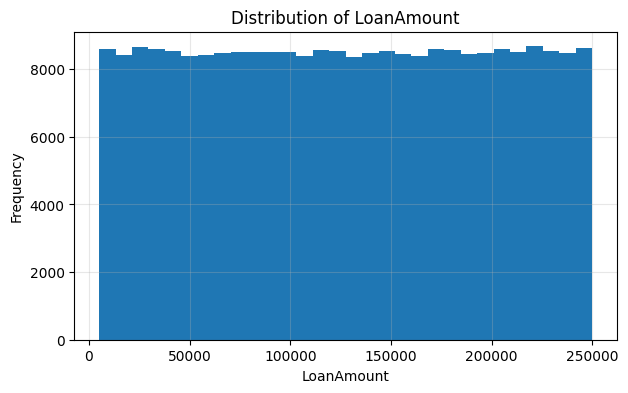

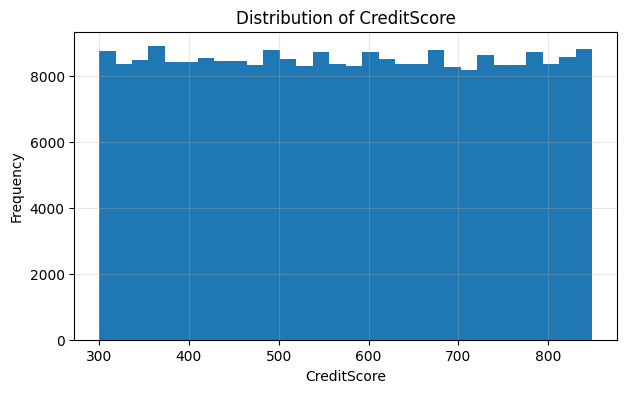

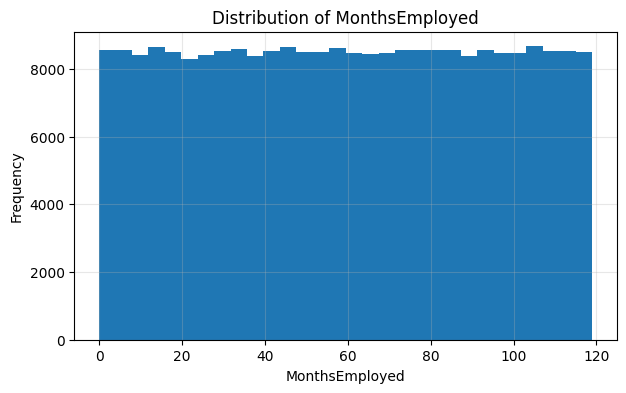

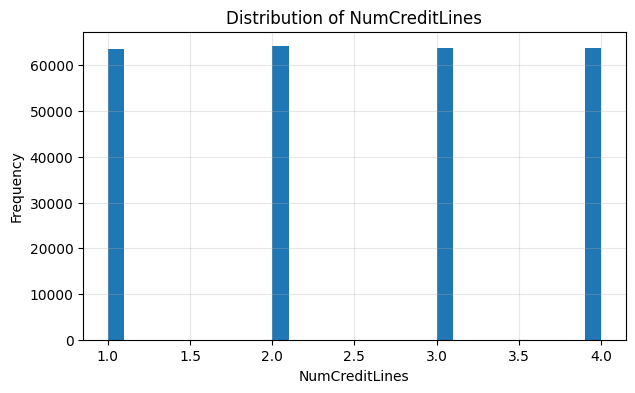

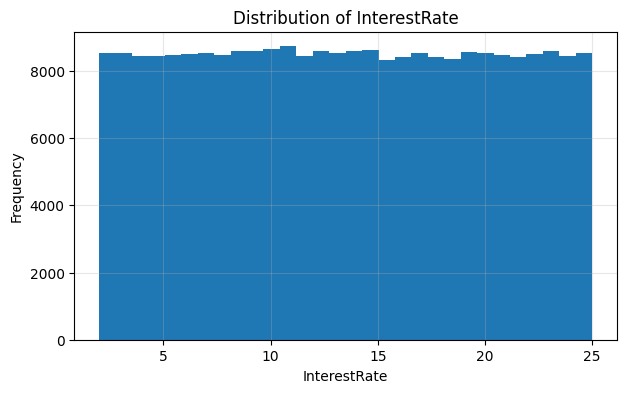

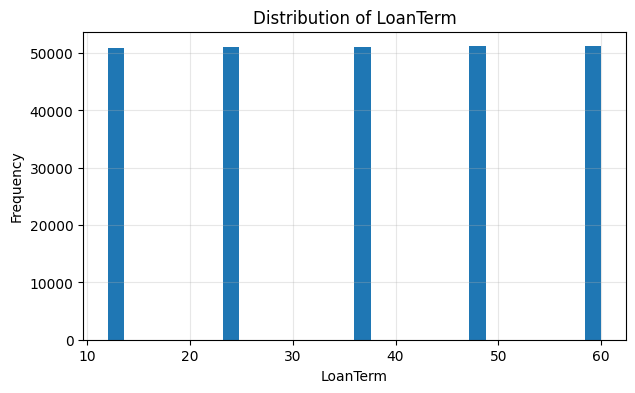

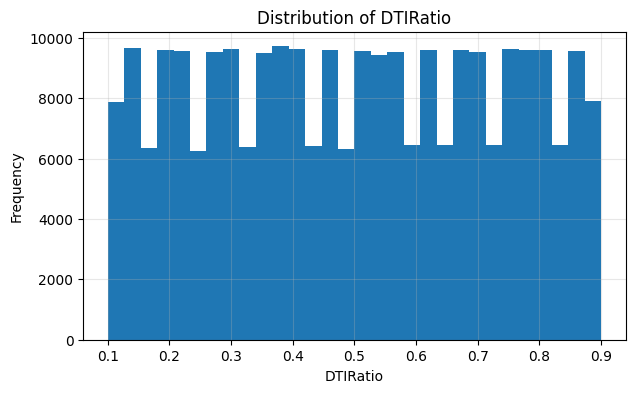

In [25]:
# Histograms

for column in numerical_columns:

    plt.figure(figsize=(7,4))
    plt.hist(df[column], bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()

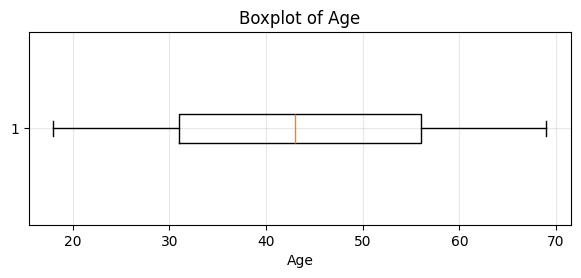

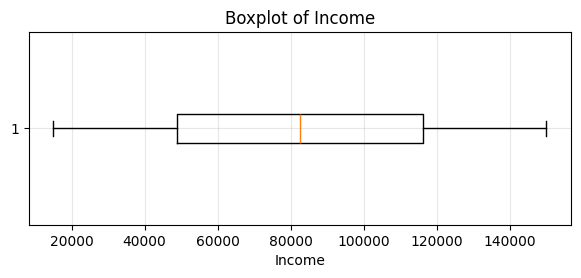

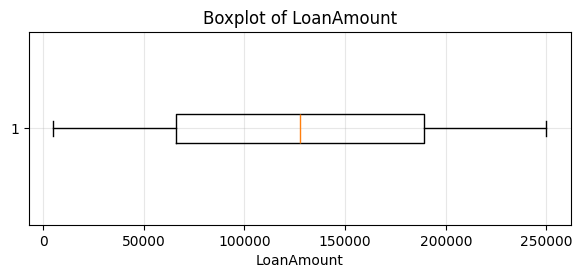

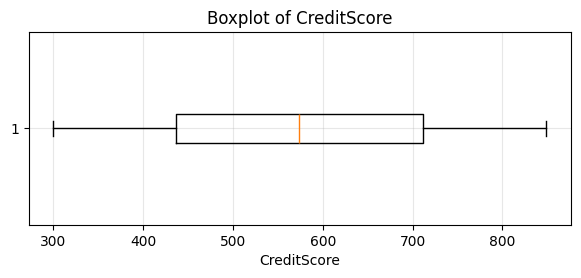

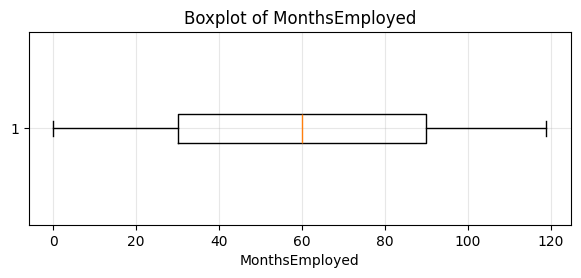

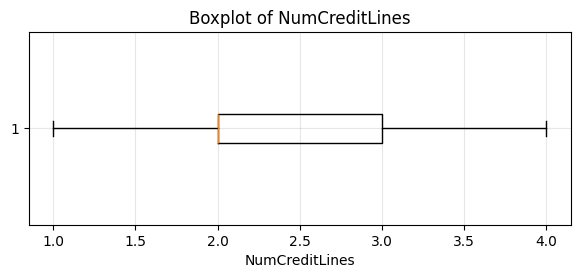

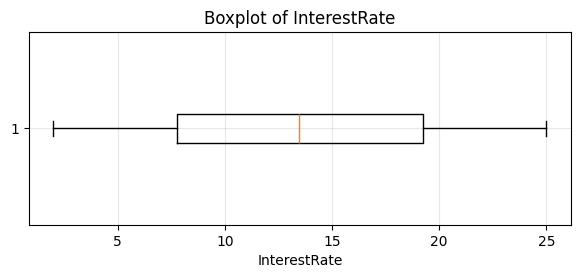

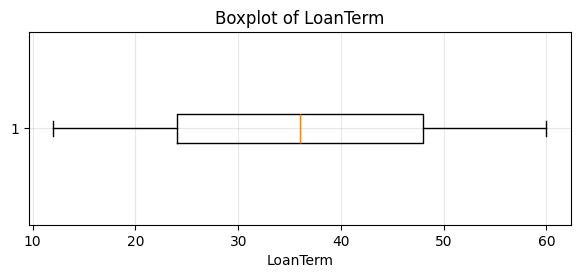

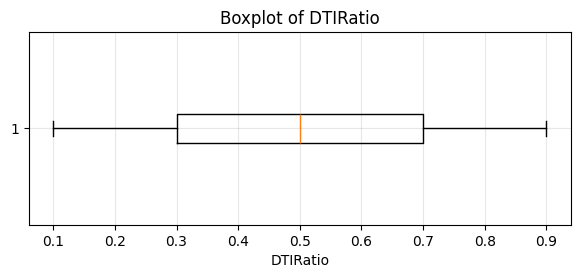

In [26]:
# Boxplots
# Detecting outliers

for column in numerical_columns:

    plt.figure(figsize=(7,2.5))
    plt.boxplot(df[column], vert=False)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.grid(alpha=0.3)
    plt.show()

In [27]:
# Quantify skewness

skewness = df[numerical_columns].skew()
skewness

,0
Age,0.000698
Income,-0.000381
LoanAmount,-0.001827
CreditScore,0.004688
MonthsEmployed,-0.002142
NumCreditLines,-0.000278
InterestRate,0.004608
LoanTerm,-0.002178
DTIRatio,-0.001499


Interpretation of skewness

-0.5 to 0.5 = Aproximately symmetric

0.5 to 1 = Moderately biased

Greater than 1 = Very biased

In [28]:
# Kurtosis
# Assess data concentration and the presence of heavy tails(outliers).

kurtosis = df[numerical_columns].kurt()
kurtosis

,0
Age,-1.198431
Income,-1.198361
LoanAmount,-1.203680
CreditScore,-1.200302
MonthsEmployed,-1.199632
NumCreditLines,-1.357671
InterestRate,-1.197167
LoanTerm,-1.299895
DTIRatio,-1.199675


Interpretation of kurtosis

≈0 is similar to a normal disstribution

Greater than 0 = heavy tails or outliers

Less than 0 = flat distribution

In [29]:
# Summary table

summary_distribution = pd.DataFrame({

    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Std': df[numerical_columns].std(),
    'Skewness': df[numerical_columns].skew(),
    'Kurtosis': df[numerical_columns].kurt()

})

summary_distribution

,Mean,Median,Std,Skewness,Kurtosis
Age,43.498306,43.00,14.990258,0.000698,-1.198431
Income,82499.304597,82466.00,38963.013729,-0.000381,-1.198361
LoanAmount,127578.865512,127556.00,70840.706142,-0.001827,-1.203680
CreditScore,574.264346,574.00,158.903867,0.004688,-1.200302
MonthsEmployed,59.541976,60.00,34.643376,-0.002142,-1.199632
NumCreditLines,2.501036,2.00,1.117018,-0.000278,-1.357671
InterestRate,13.492773,13.46,6.636443,0.004608,-1.197167
LoanTerm,36.025894,36.00,16.969330,-0.002178,-1.299895
DTIRatio,0.500212,0.50,0.230917,-0.001499,-1.199675


**6. CATEGORICAL VARIABLES**

In [30]:
# Define categorical variables

categorical_columns = [

    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'

]

In [31]:
# Absolute frequency

for column in categorical_columns:

    print("="*50)
    print(column)
    print(df[column].value_counts())

Education
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64
EmploymentType
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64
MaritalStatus
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64
HasMortgage
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64
HasDependents
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64
LoanPurpose
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64
HasCoSigner
HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64


In [32]:
# Relative frequency

for column in categorical_columns:

    print("="*50)
    print(column)
    print(round(df[column].value_counts(normalize=True)*100,2))

Education
Education
Bachelor's     25.21
High School    25.03
Master's       24.88
PhD            24.88
Name: proportion, dtype: float64
EmploymentType
EmploymentType
Part-time        25.13
Unemployed       25.00
Self-employed    24.95
Full-time        24.93
Name: proportion, dtype: float64
MaritalStatus
MaritalStatus
Married     33.41
Divorced    33.30
Single      33.29
Name: proportion, dtype: float64
HasMortgage
HasMortgage
Yes    50.0
No     50.0
Name: proportion, dtype: float64
HasDependents
HasDependents
Yes    50.03
No     49.97
Name: proportion, dtype: float64
LoanPurpose
LoanPurpose
Business     20.09
Home         20.08
Education    19.97
Other        19.94
Auto         19.91
Name: proportion, dtype: float64
HasCoSigner
HasCoSigner
Yes    50.01
No     49.99
Name: proportion, dtype: float64


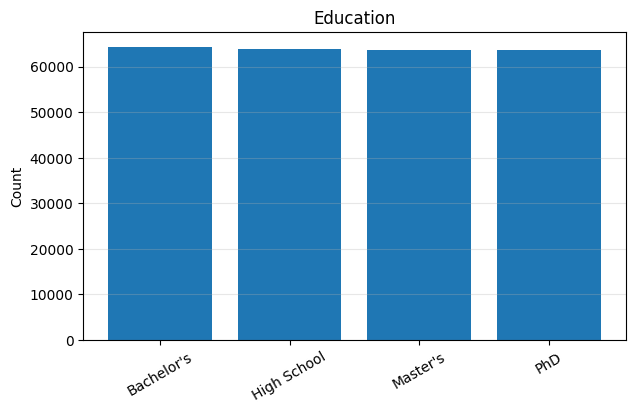

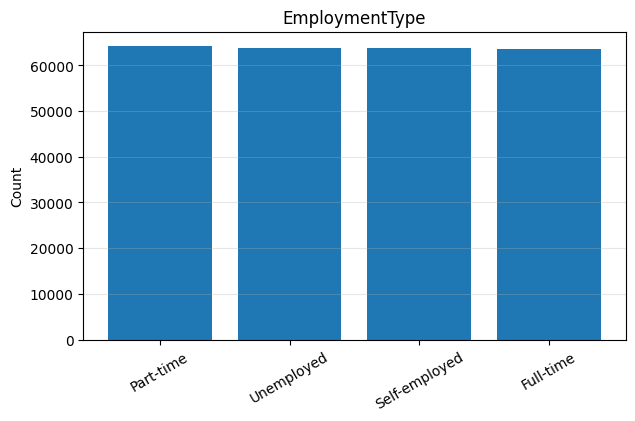

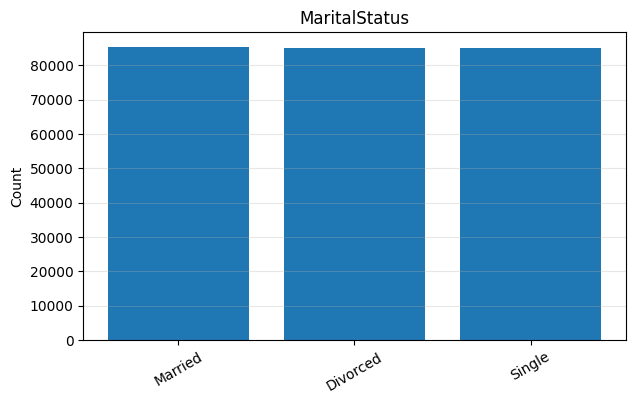

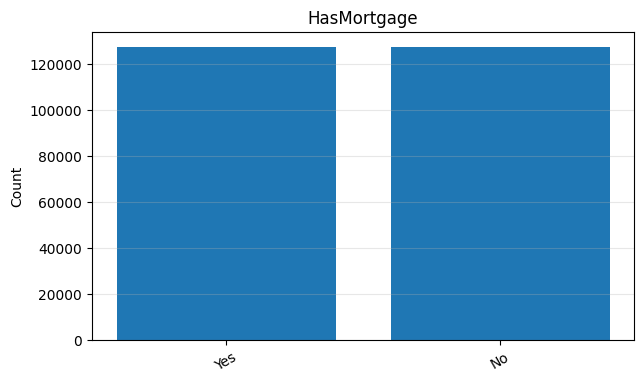

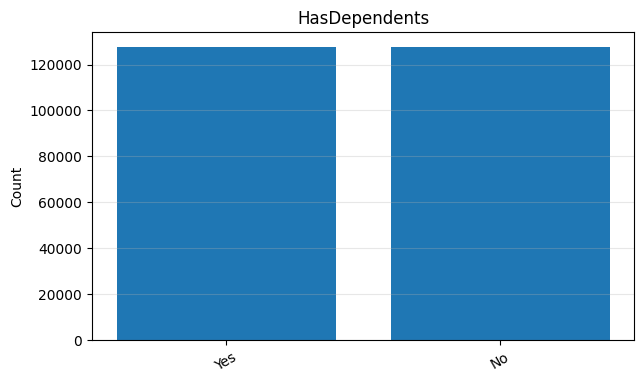

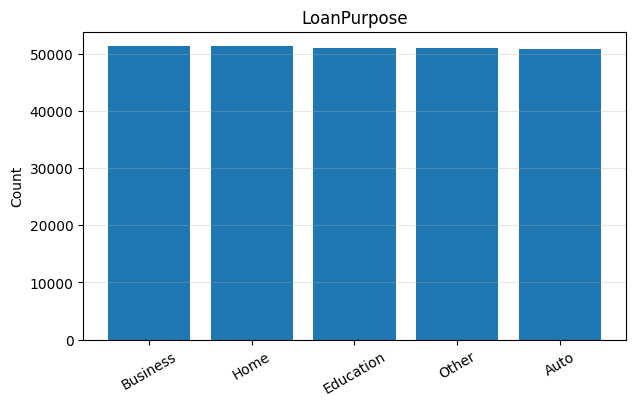

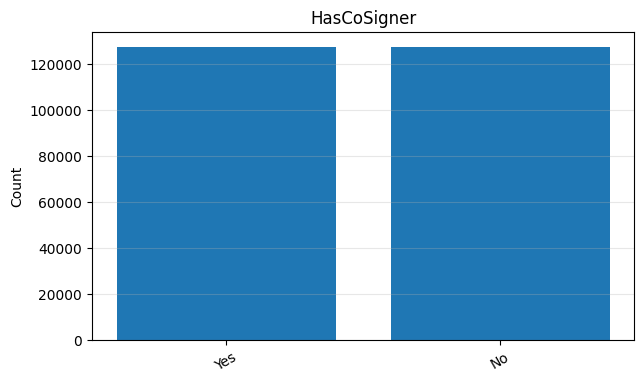

In [33]:
# Graphs

for column in categorical_columns:

    counts = df[column].value_counts()
    plt.figure(figsize=(7,4))
    plt.bar(counts.index, counts.values)
    plt.title(column)
    plt.xticks(rotation=30)
    plt.ylabel("Count")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

**7. BUSINESS RULE VALIDATION**

In [34]:
# Age

df["Age"].between(18,69).all()

# Income

(df["Income"]>0).all()

# Loan amount

(df["LoanAmount"]>0).all()

# Credit score

df["CreditScore"].between(300,850).all()

# Interest rate

df["InterestRate"].between(2,25).all()

# Loan term

df["LoanTerm"].between(12,60).all()

# DTI (Debt-to-income)

df["DTIRatio"].between(0.1,0.9).all()

np.True_

**8. CORRELATION**

In [35]:
corr = df[numerical_columns].corr()
corr

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000


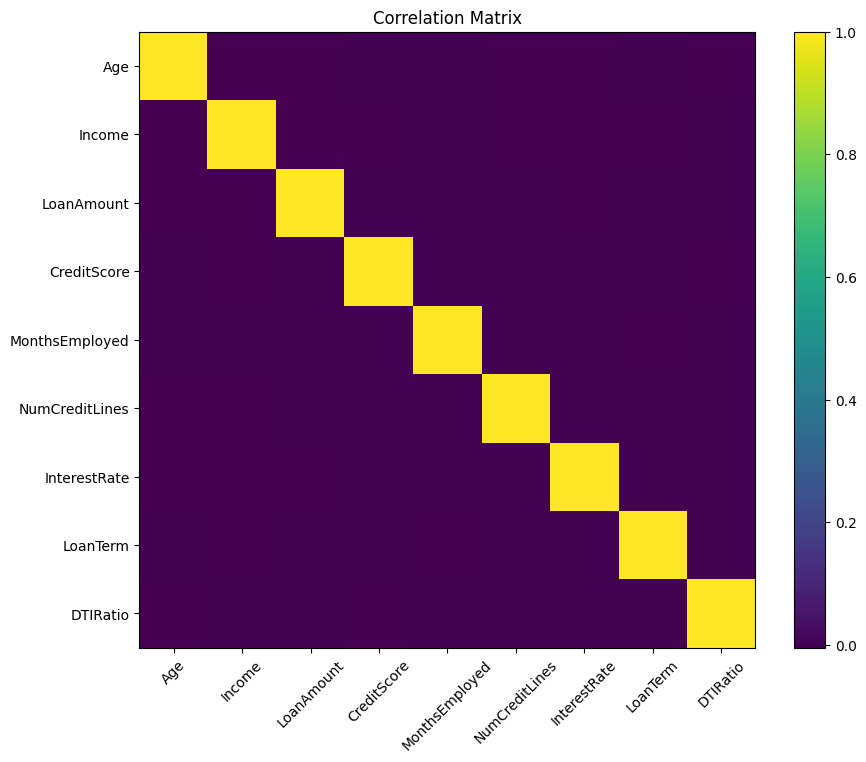

In [36]:
# Heatmap

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.show()

**9. DATA QUALITY REPORT**

In [37]:
quality_report = pd.DataFrame({

    "Aspect":[

        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Duplicate LoanID",
        "Default Rate"

    ],

    "Result":[

        len(df),
        df.shape[1],
        "0%",
        0,
        df["LoanID"].duplicated().sum(),
        f"{round(df['Default'].mean()*100,2)}%"

    ],

    "Assessment":[

        "Excellent",
        "Adequate",
        "Excellent",
        "Excellent",
        "Excellent",
        "Moderate imbalance"

    ]

})

quality_report

,Aspect,Result,Assessment
0,Rows,255347,Excellent
1,Columns,18,Adequate
2,Missing Values,0%,Excellent
3,Duplicate Rows,0,Excellent
4,Duplicate LoanID,0,Excellent
5,Default Rate,11.61%,Moderate imbalance
